In [12]:
import matplotlib.pyplot as plt
from data_loader import load_glass
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.neighbors import KNeighborsClassifier, NearestCentroid
import numpy as np
import time
import pandas as pd


In [13]:
glass = load_glass("glass")
X, y = glass["x"], glass["y"]
feature_names = glass.get("feature_names", None)
class_names = glass.get("class_names", None)

print("X:", X.shape, "y:", y.shape)
print("classes (mapped):", np.unique(y))
if class_names is not None:
    print("class_names:", class_names)


X: (214, 9) y: (214,)
classes (mapped): [0 1 2 3 4 5]
class_names: {0: 'building_windows_float_processed', 1: 'building_windows_non_float_processed', 2: 'vehicle_windows_float_processed', 3: 'containers', 4: 'tableware', 5: 'headlamps'}


In [14]:
len(X[0])

9

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=0,
    stratify=y,
)
print(X_train.shape, X_test.shape)


(149, 9) (65, 9)


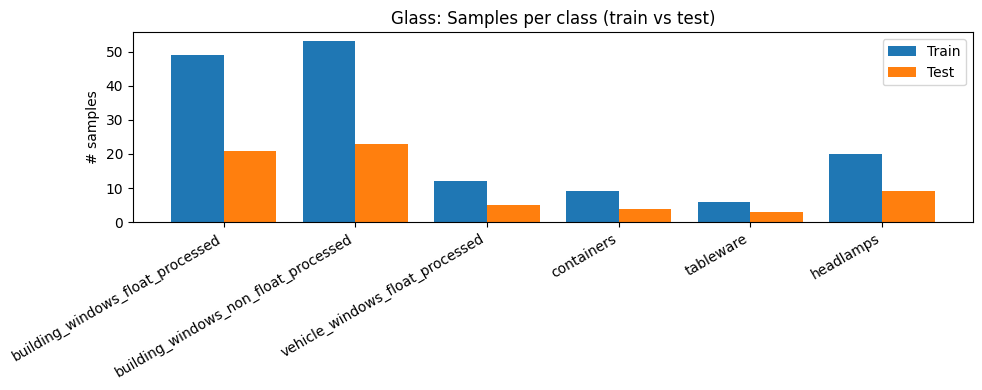

Train counts: {'building_windows_float_processed': np.int64(49), 'building_windows_non_float_processed': np.int64(53), 'vehicle_windows_float_processed': np.int64(12), 'containers': np.int64(9), 'tableware': np.int64(6), 'headlamps': np.int64(20)}
Test counts : {'building_windows_float_processed': np.int64(21), 'building_windows_non_float_processed': np.int64(23), 'vehicle_windows_float_processed': np.int64(5), 'containers': np.int64(4), 'tableware': np.int64(3), 'headlamps': np.int64(9)}


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

all_classes = np.unique(np.concatenate([y_train, y_test]))
all_classes = np.sort(all_classes)

if class_names is not None:
    x_labels = [class_names[c] if c < len(class_names) else str(c) for c in all_classes]
else:
    x_labels = [str(c) for c in all_classes]


train_counts = np.array([(y_train == c).sum() for c in all_classes])
test_counts  = np.array([(y_test  == c).sum() for c in all_classes])

x = np.arange(len(all_classes))
width = 0.40

plt.figure(figsize=(10, 4))
plt.bar(x - width/2, train_counts, width, label="Train")
plt.bar(x + width/2, test_counts,  width, label="Test")

plt.xticks(x, x_labels, rotation=30, ha="right")
plt.ylabel("# samples")
plt.title("Glass: Samples per class (train vs test)")
plt.legend()
plt.tight_layout()
plt.show()

# (Προαιρετικο) Εκτυπωση πινακα
print("Train counts:", dict(zip(x_labels, train_counts)))
print("Test counts :", dict(zip(x_labels, test_counts)))



Cross-validation strategy

In [17]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)

In [18]:
results_glass = []

Grid search for k-Nearest Neighbors (kNN)

In [19]:
knn_param_grid = {
    "n_neighbors": [1, 3, 5, 7, 9, 11, 15, 21],
    "metric": ["euclidean", "manhattan"],
    "weights": ["uniform", "distance"],
}

knn = KNeighborsClassifier()

knn_grid = GridSearchCV(
    estimator=knn,
    param_grid=knn_param_grid,
    scoring="f1_macro",
    cv=cv,
    n_jobs=-1
)

start = time.perf_counter()
knn_grid.fit(X_train, y_train)
knn_time = time.perf_counter() - start

print("Best kNN params:", knn_grid.best_params_)
print("Best CV macro f1:", knn_grid.best_score_)
print(f"Grid search train time: {knn_time:.4f} sec")


Best kNN params: {'metric': 'euclidean', 'n_neighbors': 3, 'weights': 'distance'}
Best CV macro f1: 0.6620748896835853
Grid search train time: 0.1698 sec


In [ ]:
cv_res = pd.DataFrame(knn_grid.cv_results_)

cols = (
    [c for c in cv_res.columns if c.startswith("param_")] +
    ["mean_test_score", "std_test_score", "rank_test_score",
     "mean_fit_time", "std_fit_time", "mean_score_time", "std_score_time"]
)

results_table = cv_res[cols].sort_values(["rank_test_score", "mean_test_score"], ascending=[True, False])

results_table = results_table.reset_index(drop=True)
results_table[["mean_test_score","std_test_score"]] = results_table[["mean_test_score","std_test_score"]].round(4)

# display(results_table)


# Top-5 configurations
display(results_table.head(5))


,param_metric,param_n_neighbors,param_weights,mean_test_score,std_test_score,rank_test_score,mean_fit_time,std_fit_time,mean_score_time,std_score_time
0,euclidean,3,distance,0.6621,0.1407,1,0.002427,0.000428,0.011350,0.005412
1,euclidean,3,uniform,0.6550,0.1198,2,0.002302,0.000608,0.012939,0.003133
2,manhattan,3,distance,0.6538,0.1269,3,0.001732,0.000724,0.005831,0.002926
3,manhattan,5,distance,0.6487,0.0890,4,0.002075,0.000409,0.006877,0.000713
4,manhattan,1,uniform,0.6396,0.1510,5,0.001671,0.000825,0.006997,0.001817


In [20]:
best_knn = knn_grid.best_estimator_

y_pred_knn = best_knn.predict(X_test)
knn_test_acc = accuracy_score(y_test, y_pred_knn)
knn_test_f1_macro = f1_score(y_test, y_pred_knn, average="macro")
knn_test_f1_weighted = f1_score(y_test, y_pred_knn, average="weighted")

print("\n=== kNN on glass test set ===")
print(f"Test accuracy     : {knn_test_acc:.4f}")
print(f"Test F1 (macro)   : {knn_test_f1_macro:.4f}")
print(f"Test F1 (weighted): {knn_test_f1_weighted:.4f}")
print("\nkNN classification report:")
print(classification_report(y_test, y_pred_knn))

cm_knn = confusion_matrix(y_test, y_pred_knn)
print("kNN confusion matrix:\n", cm_knn)

results_glass.append({
    "name": f"GLASS_kNN_best_{knn_grid.best_params_}",
    "train_time": knn_time,
    "test_accuracy": knn_test_acc,
    "test_f1_macro": knn_test_f1_macro,
    "test_f1_weighted": knn_test_f1_weighted,
})



=== kNN on glass test set ===
Test accuracy     : 0.6923
Test F1 (macro)   : 0.6409
Test F1 (weighted): 0.7056

kNN classification report:
              precision    recall  f1-score   support

           0       0.71      0.71      0.71        21
           1       0.78      0.78      0.78        23
           2       0.12      0.20      0.15         5
           3       0.67      0.50      0.57         4
           4       1.00      0.67      0.80         3
           5       0.88      0.78      0.82         9

    accuracy                           0.69        65
   macro avg       0.69      0.61      0.64        65
weighted avg       0.73      0.69      0.71        65

kNN confusion matrix:
 [[15  2  4  0  0  0]
 [ 2 18  3  0  0  0]
 [ 3  1  1  0  0  0]
 [ 0  1  0  2  0  1]
 [ 0  0  0  1  2  0]
 [ 1  1  0  0  0  7]]


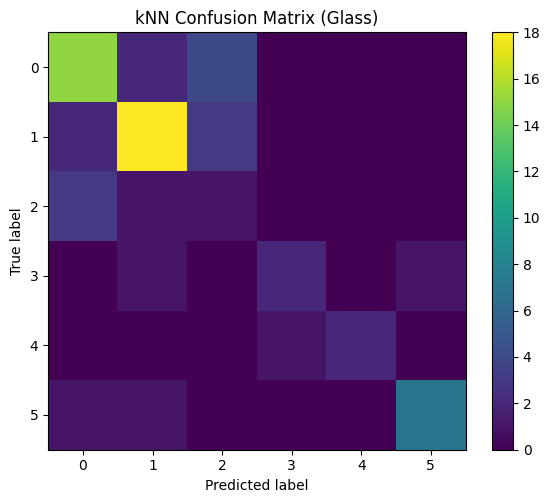

In [21]:
# visualize confusion matrix
plt.figure(figsize=(6, 5))
plt.imshow(cm_knn, interpolation="nearest")
plt.title("kNN Confusion Matrix (Glass)")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.colorbar()
plt.tight_layout()
plt.show()


Grid search for Nearest Class Centroid (NCC)

In [22]:
ncc_param_grid = {
    "metric": ["euclidean", "manhattan"],
    "shrink_threshold": [None, 0.05, 0.1, 0.5, 1.0],
}

ncc = NearestCentroid()

ncc_grid = GridSearchCV(
    estimator=ncc,
    param_grid=ncc_param_grid,
    scoring="f1_macro",
    cv=cv,
    n_jobs=-1
)

start = time.perf_counter()
ncc_grid.fit(X_train, y_train)
ncc_time = time.perf_counter() - start

print("Best NCC params:", ncc_grid.best_params_)
print("Best CV macro f1:", ncc_grid.best_score_)
print(f"Grid search train time: {ncc_time:.4f} sec")


Best NCC params: {'metric': 'manhattan', 'shrink_threshold': 0.05}
Best CV macro f1: 0.5557187022357299
Grid search train time: 0.0659 sec


In [23]:
best_ncc = ncc_grid.best_estimator_

y_pred_ncc = best_ncc.predict(X_test)
ncc_test_acc = accuracy_score(y_test, y_pred_ncc)
ncc_test_f1_macro = f1_score(y_test, y_pred_ncc, average="macro")
ncc_test_f1_weighted = f1_score(y_test, y_pred_ncc, average="weighted")

print("\n=== Nearest Class Centroid on glass test set ===")
print(f"Test accuracy     : {ncc_test_acc:.4f}")
print(f"Test F1 (macro)   : {ncc_test_f1_macro:.4f}")
print(f"Test F1 (weighted): {ncc_test_f1_weighted:.4f}")
print("\nNCC classification report:")
print(classification_report(y_test, y_pred_ncc))

cm_ncc = confusion_matrix(y_test, y_pred_ncc)
print("NCC confusion matrix:\n", cm_ncc)

results_glass.append({
    "name": f"GLASS_NCC_best_{ncc_grid.best_params_}",
    "train_time": ncc_time,
    "test_accuracy": ncc_test_acc,
    "test_f1_macro": ncc_test_f1_macro,
    "test_f1_weighted": ncc_test_f1_weighted,
})



=== Nearest Class Centroid on glass test set ===
Test accuracy     : 0.4308
Test F1 (macro)   : 0.4687
Test F1 (weighted): 0.4698

NCC classification report:
              precision    recall  f1-score   support

           0       0.60      0.29      0.39        21
           1       0.60      0.39      0.47        23
           2       0.12      0.60      0.21         5
           3       0.40      0.50      0.44         4
           4       0.40      0.67      0.50         3
           5       1.00      0.67      0.80         9

    accuracy                           0.43        65
   macro avg       0.52      0.52      0.47        65
weighted avg       0.60      0.43      0.47        65

NCC confusion matrix:
 [[ 6  3 12  0  0  0]
 [ 3  9  8  2  1  0]
 [ 1  1  3  0  0  0]
 [ 0  0  1  2  1  0]
 [ 0  0  0  1  2  0]
 [ 0  2  0  0  1  6]]


In [ ]:
cv_res = pd.DataFrame(ncc_grid.cv_results_)


cols = (
    [c for c in cv_res.columns if c.startswith("param_")] +
    ["mean_test_score", "std_test_score", "rank_test_score",
     "mean_fit_time", "std_fit_time", "mean_score_time", "std_score_time"]
)

results_table = cv_res[cols].sort_values(["rank_test_score", "mean_test_score"], ascending=[True, False])

results_table = results_table.reset_index(drop=True)
results_table[["mean_test_score","std_test_score"]] = results_table[["mean_test_score","std_test_score"]].round(4)

# display(results_table)


# Top-5 configurations
display(results_table.head(5))

,param_metric,param_shrink_threshold,mean_test_score,std_test_score,rank_test_score,mean_fit_time,std_fit_time,mean_score_time,std_score_time
0,manhattan,0.05,0.5557,0.1260,1,0.002263,0.000337,0.004116,0.000874
1,manhattan,None,0.5484,0.1294,2,0.002659,0.000350,0.005139,0.001216
2,manhattan,0.1,0.5425,0.1157,3,0.002722,0.000938,0.005430,0.001492
3,manhattan,0.5,0.5227,0.1246,4,0.002928,0.000671,0.005011,0.001768
4,euclidean,0.5,0.5125,0.0993,5,0.002694,0.000611,0.004979,0.001068


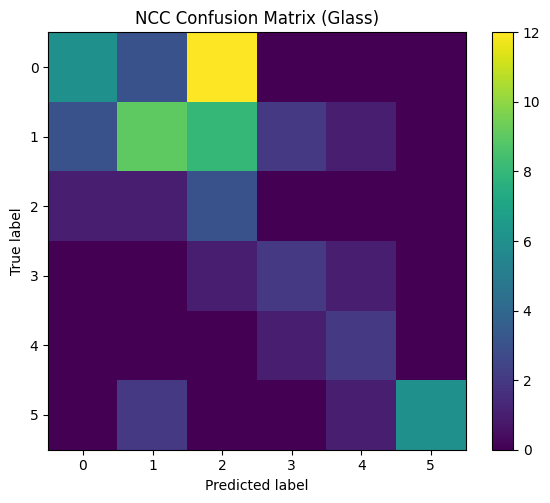

In [24]:
# visualize confusion matrix
plt.figure(figsize=(6, 5))
plt.imshow(cm_ncc, interpolation="nearest")
plt.title("NCC Confusion Matrix (Glass)")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.colorbar()
plt.tight_layout()
plt.show()


Summary

In [25]:
print("\n=== Summary kNN / NCC on glass ===")
for r in results_glass:
    print(
        f"{r['name']}\n"
        f"  train_time       = {r['train_time']:.4f} sec\n"
        f"  test_acc         = {r['test_accuracy']:.4f}\n"
        f"  test_F1_macro    = {r['test_f1_macro']:.4f}\n"
        f"  test_F1_weighted = {r['test_f1_weighted']:.4f}\n"
    )



=== Summary kNN / NCC on glass ===
GLASS_kNN_best_{'metric': 'euclidean', 'n_neighbors': 3, 'weights': 'distance'}
  train_time       = 0.1698 sec
  test_acc         = 0.6923
  test_F1_macro    = 0.6409
  test_F1_weighted = 0.7056

GLASS_NCC_best_{'metric': 'manhattan', 'shrink_threshold': 0.05}
  train_time       = 0.0659 sec
  test_acc         = 0.4308
  test_F1_macro    = 0.4687
  test_F1_weighted = 0.4698

